In [1]:
# Automatic Google Colab setup: clones the repo to access the .py module
# and the dataset in this folder (no effect when run locally).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Base-Algorithms/01-Linear-Regression-Gradient-Descent")
    get_ipython().system('pip install -q openpyxl')


# Simple Linear Regression via Gradient Descent

Translated from `Codigo01_SalarioExperiencia_BackPropagation.R`.

This notebook implements **gradient descent (backpropagation)** to fit a
simple linear regression, comparing the result against the closed-form
**ordinary least squares (OLS)** solution.

## Theory

The model is:

$$\hat{y}_i = \beta_0 + \beta_1 x_i$$

The cost function is the sum of squared errors (SSE):

$$SSE(\beta_0, \beta_1) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

For simple linear regression, SSE as a function of $(\beta_0, \beta_1)$ is a
**convex, bowl-shaped surface** (a paraboloid): no matter where we start,
there is a single minimum point — the point where both partial derivatives
of SSE are simultaneously zero.

**Gradient of the SSE.** Differentiating SSE with respect to each parameter:

$$\frac{\partial SSE}{\partial \beta_0} = -2\sum_i (y_i - \hat{y}_i), \qquad
\frac{\partial SSE}{\partial \beta_1} = -2\sum_i (y_i - \hat{y}_i) x_i$$

(the code uses these expressions without the factor of 2 — it only rescales
the learning rate, it does not change the gradient's direction).

**OLS vs. Gradient Descent — why they land on the same point.** OLS solves
the system $\partial SSE/\partial\beta_0 = 0$, $\partial SSE/\partial\beta_1 = 0$
**algebraically, in one shot** ($\hat{\beta} = (X^TX)^{-1}X^Ty$). Gradient
descent reaches the same point a different way: at every step it moves in
the direction opposite to the gradient (downhill, inside the bowl). Since
the bowl has a **single** bottom, and the algorithm only knows how to go
down, it has nowhere else to go — it eventually stops at exactly the same
point that OLS computes in one closed-form step. The difference between the
two methods is *how* they get there (direct computation vs. step by step),
not *where* they end up.

$$\beta_0 \leftarrow \beta_0 - \eta \frac{\partial SSE}{\partial \beta_0}, \qquad
\beta_1 \leftarrow \beta_1 - \eta \frac{\partial SSE}{\partial \beta_1}$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from linear_regression_gd import load_data, fit_ols, fit_gradient_descent

plt.rcParams["figure.figsize"] = (7, 4.5)


## Data

`Salary x Experience` dataset (27 observations): salary (in units of a
reference value) as a function of years of experience.


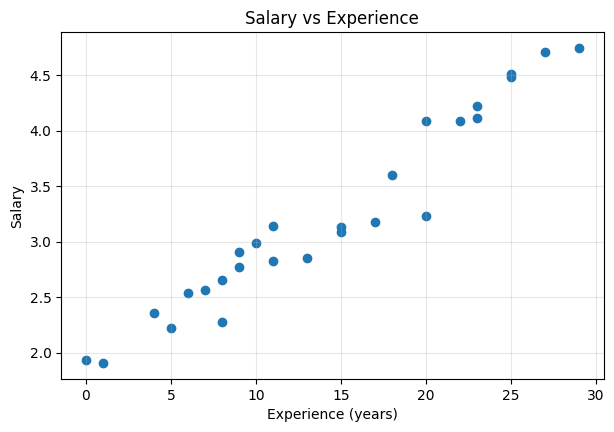

In [3]:
dt = load_data("data/SalarioExperiencia.xlsx")
x = dt["Experiencia"].to_numpy(dtype=float)
y = dt["Salario"].to_numpy(dtype=float)

plt.scatter(x, y, color="tab:blue")
plt.xlabel("Experience (years)")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.grid(alpha=0.3)
plt.show()


## OLS fit (closed-form solution)

In [4]:
ols_intercept, ols_slope = fit_ols(x, y)
print(f"OLS -> intercept: {ols_intercept:.4f}, slope: {ols_slope:.4f}")


OLS -> intercept: 1.8063, slope: 0.1008


## Gradient Descent fit

### Choosing the hyperparameters

- **`Learning rate = 0.0001`**: the gradients here are **not normalized** —
  they are raw sums over the 27 observations, with `Experience` ranging
  from 0 to 29. This already produces gradients of large magnitude, so the
  learning rate needs to be tiny so that each step doesn't overshoot the
  minimum by too much. This is the same rate used in the original R script.
- **`Steps = 10,000`**: enough for the SSE to stabilize (see the
  convergence plot below) at negligible computational cost, given the
  dataset's size.

### What happens with a larger learning rate?

With a rate 100x larger (`lr = 0.01`), the effect is not "converging more
slowly" — it is **diverging**: each step overshoots the minimum, the error
increases instead of decreasing, and since the next gradient depends on the
current error, it grows too. It's a snowball that explodes in a few
iterations, as the cell below shows.


In [5]:
gd_result = fit_gradient_descent(x, y, learning_rate=0.0001, n_steps=10_000)
print(f"Gradient descent -> intercept: {gd_result.intercept:.4f}, slope: {gd_result.slope:.4f}")


Gradient descent -> intercept: 1.8041, slope: 0.1009


In [6]:
# Demonstration: what happens with a 100x larger learning rate
_diverge_result = fit_gradient_descent(x, y, learning_rate=0.01, n_steps=50)
print("SSE after 50 steps with lr=0.0001 (reference): tens")
print(f"SSE after 50 steps with lr=0.01               : {_diverge_result.sse_history[-1]:.3e}")


SSE after 50 steps with lr=0.0001 (reference): tens
SSE after 50 steps with lr=0.01               : 2.547e+187


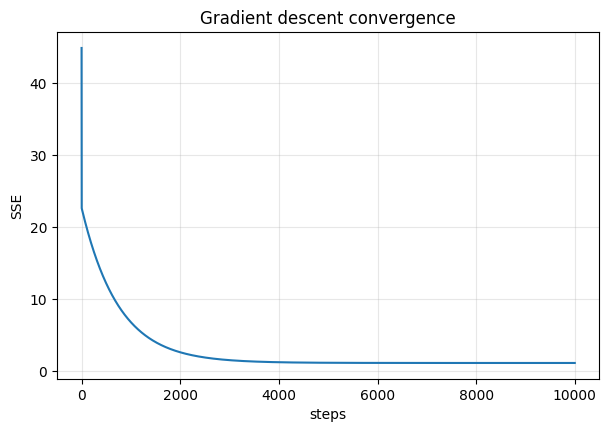

In [7]:
plt.plot(gd_result.sse_history, color="tab:blue")
plt.xlabel("steps")
plt.ylabel("SSE")
plt.title("Gradient descent convergence")
plt.grid(alpha=0.3)
plt.show()


## Visual comparison of both solutions

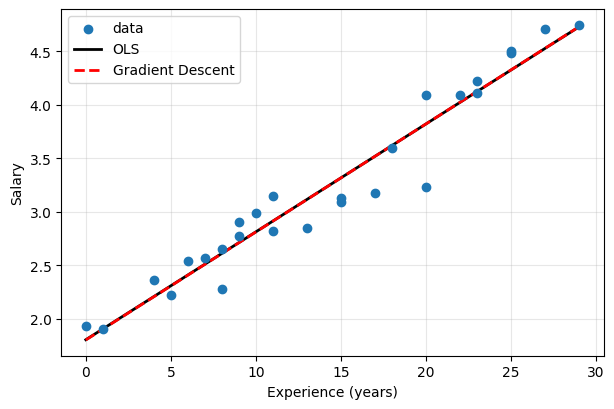

In [8]:
x_grid = np.linspace(x.min(), x.max(), 100)

plt.scatter(x, y, color="tab:blue", label="data", zorder=3)
plt.plot(x_grid, ols_intercept + ols_slope * x_grid, color="black", lw=2, label="OLS")
plt.plot(
    x_grid, gd_result.intercept + gd_result.slope * x_grid,
    color="red", lw=2, ls="--", label="Gradient Descent",
)
plt.xlabel("Experience (years)")
plt.ylabel("Salary")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Interpreting the metrics

Since the problem is convex, gradient descent with a suitable learning rate
and number of steps converges to (practically) the same solution as OLS.
The metrics below confirm that R² and RMSE for both approaches are
equivalent to a few decimal places — the small residual difference comes
only from gradient descent not having converged 100% (an iterative process,
not a closed-form one).


In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


y_pred_ols = ols_intercept + ols_slope * x
y_pred_gd = gd_result.intercept + gd_result.slope * x

print(f"OLS              -> RMSE: {rmse(y, y_pred_ols):.5f}, R2: {r_squared(y, y_pred_ols):.5f}")
print(f"Gradient Descent -> RMSE: {rmse(y, y_pred_gd):.5f}, R2: {r_squared(y, y_pred_gd):.5f}")


OLS              -> RMSE: 0.20336, R2: 0.94170
Gradient Descent -> RMSE: 0.20337, R2: 0.94170


## Conclusion

Gradient descent recovers the same line as the analytical least-squares
solution when the learning rate and number of iterations are well chosen.
This example is the conceptual foundation of **backpropagation** in neural
networks: MLPs generalize this same mechanism (updating parameters in the
direction opposite to the error gradient) to models with hidden layers and
non-linear activation functions — see `02-MLP-Manual-Backpropagation/`.
